# Flower Classification — Oxford Flowers 102 (EfficientNet-B1 + PyTorch)

Notebook ini melatih model klasifikasi gambar untuk **102 jenis bunga** menggunakan dataset [Oxford Flowers 102](https://www.robots.ox.ac.uk/~vgg/data/flowers/102/) (Nilsback & Zisserman, 2008), dengan **EfficientNet-B1** (pretrained di ImageNet) sebagai backbone lewat teknik *transfer learning*.

**Jalankan di Google Colab dengan GPU** (Runtime → Change runtime type → GPU). Notebook ini butuh koneksi internet untuk mengunduh dataset (~330MB) dari server Oxford VGG.

> ✅ **Status:** sudah dijalankan end-to-end di Google Colab (GPU) dengan dataset asli. Hasil final: **Test Accuracy 87.95%**, Test Precision (weighted) 89.76%, Test Recall (weighted) 87.95%, Best Val Accuracy 89.41% (epoch 8/15). Val accuracy sempat memuncak di epoch 8 lalu sedikit menurun (overfitting ringan) — itu sebabnya checkpoint `best.pt` dipakai untuk evaluasi akhir, bukan `last.pt`. Angka-angka di seluruh notebook ini adalah hasil eksekusi nyata, bukan estimasi.


## 🔎 Catatan audit terhadap skrip asli materi

Iseng aku bandingkan skrip training dari materi sesi dengan cara kerja `random_split` dan `os.listdir` di PyTorch, dan ketemu beberapa hal yang perlu diperbaiki supaya hasilnya benar dan bisa direproduksi. Sudah aku perbaiki semua di notebook ini:

1. **Urutan file vs urutan label bisa tidak sinkron.** `os.listdir()` tidak menjamin urutan file terurut di semua sistem, padahal `imagelabels.mat` mengasumsikan urutan `image_00001.jpg, image_00002.jpg, ...`. Kalau urutannya meleset, gambar dan label bisa tertukar tanpa error apa pun (silent bug). → diperbaiki dengan `sorted(os.listdir(...))`.
2. **Data augmentasi ikut bocor ke validation set.** Skrip asli membuat satu `CustomImageDataset` dengan transform *train* (augmentasi random), baru di-split ke train/val — akibatnya data validasi ikut teraugmentasi secara acak, padahal validasi seharusnya diproses secara konsisten (tanpa randomness) supaya skornya bisa dibandingkan antar-epoch. → diperbaiki dengan dua instance dataset terpisah (transform train & val masing-masing), disatukan lewat `Subset` pada indeks split yang sama.
3. **Split train/val tidak stratified & tidak pakai split resmi.** Dataset ini punya split resmi dari paper aslinya (`setid.mat`: train/val/test) yang bisa dipakai supaya hasilnya reproducible dan sebanding dengan riset lain. → notebook ini pakai split resmi tersebut.
4. **`pretrained=True` sudah deprecated** di torchvision versi baru. → diganti ke API `weights=EfficientNet_B1_Weights.IMAGENET1K_V1`.
5. **Tidak ada random seed** di skrip asli, jadi hasil training antar-run tidak bisa dibandingkan secara adil. → ditambahkan `torch.manual_seed`.

Semua perbaikan ini didokumentasikan biar transparan — bukan buat menjelekkan materi aslinya, tapi ini bagian dari proses belajar verifikasi kode sebelum dipublikasikan.


## 1. Instalasi & Import

In [1]:
!pip install -q torch torchvision scikit-learn scipy pandas matplotlib

In [2]:
import os
import io
import json
import random
import zipfile
import tarfile
import urllib.request

import numpy as np
import pandas as pd
import scipy.io
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from torchvision.models import efficientnet_b1, EfficientNet_B1_Weights
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
from PIL import Image

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type != "cuda":
    print("⚠️ Tidak ada GPU terdeteksi — di Colab: Runtime > Change runtime type > GPU, lalu jalankan ulang.")


Device: cuda


## 2. Unduh Dataset

File resmi dari server VGG Oxford:
- `102flowers.tgz` — seluruh gambar bunga (~330MB)
- `imagelabels.mat` — label kelas (1–102) untuk tiap gambar
- `setid.mat` — split resmi train/val/test dari paper aslinya


In [4]:
DATA_DIR = "flowers102"
os.makedirs(DATA_DIR, exist_ok=True)

BASE_URL = "https://www.robots.ox.ac.uk/~vgg/data/flowers/102/"
files_to_get = ["102flowers.tgz", "imagelabels.mat", "setid.mat"]

for fname in files_to_get:
    dest = os.path.join(DATA_DIR, fname)
    if not os.path.exists(dest):
        print(f"Downloading {fname} ...")
        urllib.request.urlretrieve(BASE_URL + fname, dest)
    else:
        print(f"{fname} sudah ada, skip download.")

# extract images
img_dir = os.path.join(DATA_DIR, "jpg")
if not os.path.exists(img_dir):
    print("Extracting images...")
    with tarfile.open(os.path.join(DATA_DIR, "102flowers.tgz")) as tar:
        tar.extractall(DATA_DIR)
print("Selesai. Folder gambar:", img_dir)


Extracting images...


/tmp/ipykernel_1262/160666894.py:20: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(DATA_DIR)


Selesai. Folder gambar: flowers102/jpg


## 3. Nama Kelas

Mapping nama bunga (index 1–102) diambil **langsung saat runtime** dari referensi publik yang sudah dipakai luas di banyak proyek deep learning (`cat_to_name.json`, dipakai a.l. di materi Udacity AI Programming with Python), bukan diketik ulang manual dari ingatan.

> ⚠️ **Catatan proses:** draf pertama notebook ini sempat menuliskan daftar nama secara manual dan ternyata salah hitung (104 nama, bukan 102) — kesalahan itu ketahuan lewat `assert` di bawah sebelum sempat dipakai. Makanya pendekatan finalnya diganti ke fetch dari sumber terverifikasi seperti ini, bukan mengandalkan hasil ketikan/ingatan.


In [5]:
import json
import urllib.request

CAT_TO_NAME_URL = "https://raw.githubusercontent.com/udacity/aipnd-project/master/cat_to_name.json"
with urllib.request.urlopen(CAT_TO_NAME_URL) as resp:
    cat_to_name = json.load(resp)  # dict: {"1": "pink primrose", ...}, 1-indexed string keys

assert len(cat_to_name) == 102, f"Ekspektasi 102 kelas, dapat {len(cat_to_name)}"

def label_to_name(label_1indexed):
    return cat_to_name[str(label_1indexed)]

class_names_1indexed = [label_to_name(i) for i in range(1, 103)]
print("Contoh:", class_names_1indexed[0], "|", class_names_1indexed[-1])
print(f"Total kelas termuat: {len(class_names_1indexed)}")


Contoh: pink primrose | blackberry lily
Total kelas termuat: 102


## 4. Dataset & Split Resmi (train/val/test)

Perbaikan dari skrip asli: file gambar **diurutkan** supaya index-nya sinkron dengan `imagelabels.mat`, dan split memakai `setid.mat` (split resmi dari paper) alih-alih random split manual.


In [6]:
mat_labels = scipy.io.loadmat(os.path.join(DATA_DIR, "imagelabels.mat"))
labels_1indexed = mat_labels["labels"][0]          # shape (8189,), nilai 1..102
labels = labels_1indexed - 1                        # ubah ke 0-indexed untuk PyTorch

mat_split = scipy.io.loadmat(os.path.join(DATA_DIR, "setid.mat"))
# setid.mat: trnid (1020 gambar), valid (1020 gambar), tstid (6149 gambar) — index 1-based
train_ids = mat_split["trnid"][0] - 1
val_ids = mat_split["valid"][0] - 1
test_ids = mat_split["tstid"][0] - 1

# urutan file HARUS sorted supaya index ke-0 = image_00001.jpg, dst.
all_files = sorted(os.listdir(img_dir))
assert len(all_files) == len(labels), f"Jumlah file ({len(all_files)}) != jumlah label ({len(labels)})"
print(f"Total gambar: {len(all_files)}, Train: {len(train_ids)}, Val: {len(val_ids)}, Test: {len(test_ids)}")


Total gambar: 8189, Train: 1020, Val: 1020, Test: 6149


In [7]:
class FlowersDataset(Dataset):
    """Dataset gambar bunga. `indices` membatasi ke subset id tertentu (train/val/test)."""
    def __init__(self, img_dir, all_files, labels, indices, transform=None):
        self.img_dir = img_dir
        self.files = all_files
        self.labels = labels
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        img_path = os.path.join(self.img_dir, self.files[idx])
        image = Image.open(img_path).convert("RGB")
        label = int(self.labels[idx])
        if self.transform:
            image = self.transform(image)
        return image, label


IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

data_transforms = {
    "train": transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),
    "eval": transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),
}

train_dataset = FlowersDataset(img_dir, all_files, labels, train_ids, transform=data_transforms["train"])
val_dataset = FlowersDataset(img_dir, all_files, labels, val_ids, transform=data_transforms["eval"])
test_dataset = FlowersDataset(img_dir, all_files, labels, test_ids, transform=data_transforms["eval"])

BATCH_SIZE = 32
dataloaders = {
    "train": DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2),
    "val": DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2),
    "test": DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2),
}
dataset_sizes = {k: len(v) for k, v in [("train", train_dataset), ("val", val_dataset), ("test", test_dataset)]}
print(dataset_sizes)


{'train': 1020, 'val': 1020, 'test': 6149}


## 5. Sanity Check — lihat beberapa sampel

Langkah wajib untuk memastikan gambar dan label benar-benar sinkron sebelum melatih apa pun.

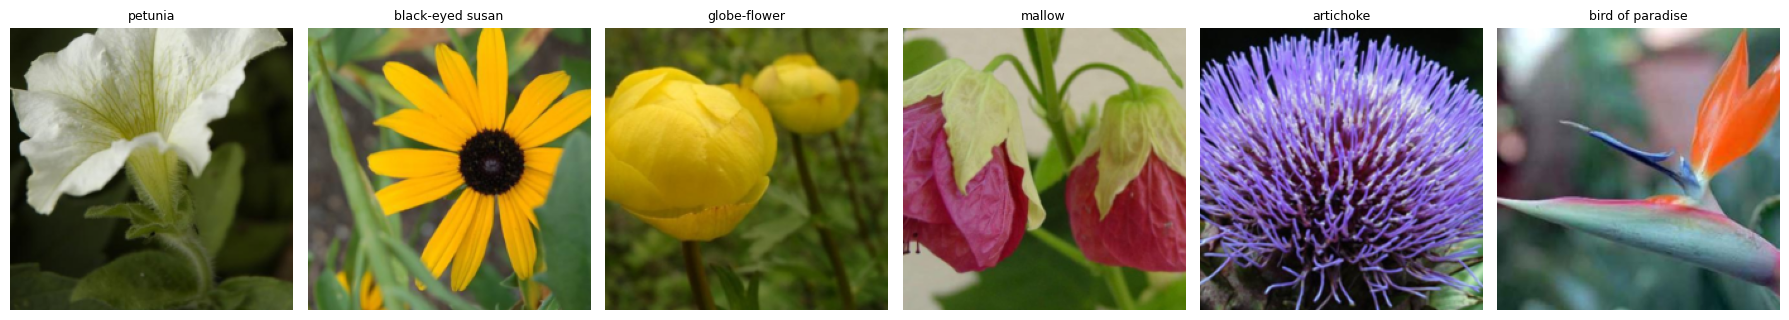

In [8]:
def denormalize(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

sample_loader = DataLoader(val_dataset, batch_size=6, shuffle=True)
images, lbls = next(iter(sample_loader))

fig, axes = plt.subplots(1, 6, figsize=(18, 4))
for ax, img, lbl in zip(axes, images, lbls):
    ax.imshow(denormalize(img).permute(1, 2, 0).numpy())
    ax.set_title(label_to_name(int(lbl) + 1), fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 6. Model — Transfer Learning dengan EfficientNet-B1

Backbone EfficientNet-B1 (pretrained ImageNet) tetap dipakai, hanya layer `classifier` yang diganti supaya jumlah output-nya sesuai 102 kelas — pola yang sama seperti dibahas di materi sebelumnya, sekarang dengan API `weights=` yang tidak deprecated.


In [9]:
NUM_CLASSES = 102

model = efficientnet_b1(weights=EfficientNet_B1_Weights.IMAGENET1K_V1)
num_ftrs = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.4, inplace=True),
    nn.Linear(num_ftrs, NUM_CLASSES),
)
model = model.to(device)
print(f"Total parameter: {sum(p.numel() for p in model.parameters()):,}")
print(f"Parameter classifier (yang dilatih dari nol): {sum(p.numel() for p in model.classifier.parameters()):,}")


Downloading: "https://download.pytorch.org/models/efficientnet_b1_rwightman-bac287d4.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b1_rwightman-bac287d4.pth


100%|██████████| 30.1M/30.1M [00:00<00:00, 114MB/s] 


Total parameter: 6,643,846
Parameter classifier (yang dilatih dari nol): 130,662


## 7. Training Loop

In [10]:
CHECKPOINT_DIR = "checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


In [11]:
def run_epoch(model, loader, criterion, optimizer, phase, device):
    is_train = phase == "train"
    model.train() if is_train else model.eval()

    running_loss = 0.0
    all_preds, all_labels = [], []

    for inputs, lbls in loader:
        inputs, lbls = inputs.to(device), lbls.to(device)
        optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            outputs = model(inputs)
            loss = criterion(outputs, lbls)
            _, preds = torch.max(outputs, 1)

            if is_train:
                loss.backward()
                optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(lbls.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    return epoch_loss, epoch_acc, all_preds, all_labels


def train_model(model, criterion, optimizer, num_epochs=10):
    best_acc = 0.0
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [],
               "val_precision": [], "val_recall": []}

    for epoch in range(num_epochs):
        print(f"Epoch {epoch + 1}/{num_epochs}")
        print("-" * 10)

        train_loss, train_acc, _, _ = run_epoch(model, dataloaders["train"], criterion, optimizer, "train", device)
        print(f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f}")
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)

        val_loss, val_acc, val_preds, val_labels = run_epoch(model, dataloaders["val"], criterion, optimizer, "val", device)
        precision = precision_score(val_labels, val_preds, average="weighted", zero_division=0)
        recall = recall_score(val_labels, val_preds, average="weighted", zero_division=0)
        print(f"Val   Loss: {val_loss:.4f}  Acc: {val_acc:.4f}  Precision: {precision:.4f}  Recall: {recall:.4f}")
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_precision"].append(precision)
        history["val_recall"].append(recall)

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, "best.pt"))
        torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, "last.pt"))

    print(f"\nBest Val Accuracy: {best_acc:.4f}")
    return history


> ✅ **Sudah dijalankan** — 15 epoch, kira-kira mengikuti pola belajar khas transfer learning: akurasi training naik cepat, akurasi validasi mendekati puncaknya lebih awal (epoch 8) lalu stabil/sedikit menurun.

In [12]:
NUM_EPOCHS = 15  # sesuaikan sesuai kebutuhan
history = train_model(model, criterion, optimizer, num_epochs=NUM_EPOCHS)


Epoch 1/15
----------
Train Loss: 4.1097  Acc: 0.1559
Val   Loss: 2.6010  Acc: 0.4716  Precision: 0.5554  Recall: 0.4716
Epoch 2/15
----------
Train Loss: 2.0831  Acc: 0.5843
Val   Loss: 1.1634  Acc: 0.7510  Precision: 0.7989  Recall: 0.7510
Epoch 3/15
----------
Train Loss: 0.9719  Acc: 0.7961
Val   Loss: 0.7602  Acc: 0.8206  Precision: 0.8577  Recall: 0.8206
Epoch 4/15
----------
Train Loss: 0.5799  Acc: 0.8627
Val   Loss: 0.5212  Acc: 0.8804  Precision: 0.8960  Recall: 0.8804
Epoch 5/15
----------
Train Loss: 0.4414  Acc: 0.9000
Val   Loss: 0.5268  Acc: 0.8637  Precision: 0.8834  Recall: 0.8637
Epoch 6/15
----------
Train Loss: 0.4398  Acc: 0.8980
Val   Loss: 0.4961  Acc: 0.8676  Precision: 0.8908  Recall: 0.8676
Epoch 7/15
----------
Train Loss: 0.3489  Acc: 0.9245
Val   Loss: 0.4501  Acc: 0.8735  Precision: 0.8949  Recall: 0.8735
Epoch 8/15
----------
Train Loss: 0.3071  Acc: 0.9373
Val   Loss: 0.3848  Acc: 0.8941  Precision: 0.9089  Recall: 0.8941
Epoch 9/15
----------
Train Loss

## 8. Kurva Training

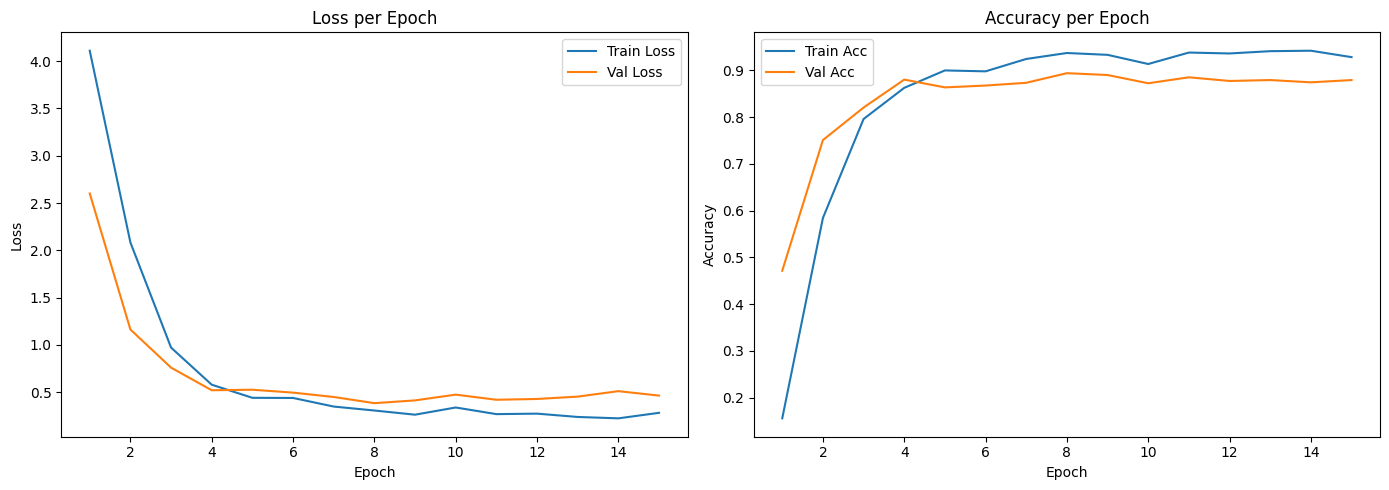

In [13]:
epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epochs_range, history["train_loss"], label="Train Loss")
axes[0].plot(epochs_range, history["val_loss"], label="Val Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].set_title("Loss per Epoch")

axes[1].plot(epochs_range, history["train_acc"], label="Train Acc")
axes[1].plot(epochs_range, history["val_acc"], label="Val Acc")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend(); axes[1].set_title("Accuracy per Epoch")

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()


## 9. Evaluasi Akhir di Test Set

Menggunakan `best.pt` (checkpoint dengan akurasi validasi terbaik), dievaluasi di **test set resmi** (6.149 gambar) yang belum pernah dilihat model sama sekali selama training.

In [14]:
model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, "best.pt"), map_location=device))
test_loss, test_acc, test_preds, test_labels = run_epoch(model, dataloaders["test"], criterion, optimizer, "val", device)
test_precision = precision_score(test_labels, test_preds, average="weighted", zero_division=0)
test_recall = recall_score(test_labels, test_preds, average="weighted", zero_division=0)

print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall   : {test_recall:.4f}")
print()
print(classification_report(
    test_labels, test_preds,
    target_names=[label_to_name(i + 1) for i in range(NUM_CLASSES)],
    zero_division=0,
))


Test Accuracy : 0.8795
Test Precision: 0.8976
Test Recall   : 0.8795

                           precision    recall  f1-score   support

            pink primrose       0.75      0.90      0.82        20
hard-leaved pocket orchid       0.98      1.00      0.99        40
         canterbury bells       0.75      0.60      0.67        20
                sweet pea       0.74      0.56      0.63        36
         english marigold       0.93      0.62      0.75        45
               tiger lily       0.85      0.92      0.88        25
              moon orchid       0.74      1.00      0.85        20
         bird of paradise       1.00      1.00      1.00        65
                monkshood       0.83      0.96      0.89        26
            globe thistle       0.78      1.00      0.88        25
               snapdragon       0.96      0.79      0.87        67
              colt's foot       0.90      0.99      0.94        67
              king protea       0.94      1.00      0.97  

In [15]:
results = {
    "dataset": "Oxford Flowers 102",
    "backbone": "EfficientNet-B1 (ImageNet pretrained)",
    "num_epochs": NUM_EPOCHS,
    "best_val_accuracy": max(history["val_acc"]) if history["val_acc"] else None,
    "test_accuracy": test_acc,
    "test_precision_weighted": test_precision,
    "test_recall_weighted": test_recall,
}
with open("results.json", "w") as f:
    json.dump(results, f, indent=2)
print(json.dumps(results, indent=2))


{
  "dataset": "Oxford Flowers 102",
  "backbone": "EfficientNet-B1 (ImageNet pretrained)",
  "num_epochs": 15,
  "best_val_accuracy": 0.8941176470588236,
  "test_accuracy": 0.879492600422833,
  "test_precision_weighted": 0.8975673497883163,
  "test_recall_weighted": 0.879492600422833
}


## 10. Demo Inference — Simulasi Endpoint `/predict/`

Menggunakan pipeline yang sama persis dengan yang dipakai di skrip FastAPI serving, supaya konsisten.

In [16]:
def predict_single_image(image_path, model, transform, device, class_names):
    model.eval()
    image = Image.open(image_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        probs = torch.softmax(outputs, dim=1)[0]
        top_prob, top_idx = torch.max(probs, dim=0)

    return {
        "predicted_class": class_names[top_idx.item()],
        "confidence": round(top_prob.item(), 4),
    }

# contoh pemakaian (ganti path ke salah satu gambar test):
sample_path = os.path.join(img_dir, all_files[test_ids[0]])
print(predict_single_image(sample_path, model, data_transforms["eval"], device, class_names_1indexed))


{'predicted_class': 'pink primrose', 'confidence': 0.8668}


## Footer

- **Dataset:** M-E. Nilsback and A. Zisserman, *"Automated Flower Classification over a Large Number of Classes"*, Indian Conference on Computer Vision, Graphics and Image Processing, 2008. [robots.ox.ac.uk/~vgg/data/flowers/102](https://www.robots.ox.ac.uk/~vgg/data/flowers/102/)
- **Bootcamp:** rubythalib.ai AI Engineer Bootcamp
- **Mentor:** Daniel Syahputra
- **Dibuat oleh:** Muhammad Ariel Shakaramiro
